# Notebook 9 — Synthesis & Final Report

**Project:** Data-Driven Cognitive Phenotyping in Acquired Brain Injury  
**Author:** Zoltan Kunos | Universitat de Barcelona  

Consolidates all results, generates publication-quality figures, and exports summary tables.

In [1]:
# === Configuration ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300

RESULTS_DIR = '../results'
IMPUTED_DIR = '../data/imputed_csv'
FIGURES_DIR = '../report template/Figures'

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load all results
with open(os.path.join(RESULTS_DIR, 'shared_infrastructure.pkl'), 'rb') as f:
    infra = pickle.load(f)

# H1: load improved per-method bootstrap pickle (NB6) and synthesise the legacy
# verdict/mean_jaccard/mean_silhouette fields the synthesis code expects.
with open(os.path.join(RESULTS_DIR, 'h1_improved.pkl'), 'rb') as f:
    h1_raw = pickle.load(f)
n_passing = h1_raw.get('n_passing', 0)
per_method = h1_raw.get('per_method', {})
mean_j = sum(r.get('overall_core_jaccard', 0) for r in per_method.values()) / max(len(per_method), 1)
mean_s = sum(r.get('sil_boot_median', 0) for r in per_method.values()) / max(len(per_method), 1)
h1 = {
    'verdict': 'Supported' if n_passing >= 8 else 'Partially Supported',
    'mean_jaccard': round(mean_j, 3),
    'mean_silhouette': round(mean_s, 3),
    'n_passing': n_passing,
    'n_methods': h1_raw.get('n_methods', 10),
    'per_method': per_method,
}

with open(os.path.join(RESULTS_DIR, 'h2_results.pkl'), 'rb') as f:
    h2 = pickle.load(f)
with open(os.path.join(RESULTS_DIR, 'h3_results.pkl'), 'rb') as f:
    h3 = pickle.load(f)
with open(os.path.join(RESULTS_DIR, 'h4_results.pkl'), 'rb') as f:
    h4 = pickle.load(f)

METHODS = infra['METHODS']
DOMAINS = infra['DOMAINS']
ELIGIBLE_VARS = infra['ELIGIBLE_VARS']

print('All results loaded.')

All results loaded.


## 1. Hypothesis Results Summary

In [3]:
hypothesis_summary = pd.DataFrame([
    {
        'Hypothesis': 'H1: Discrete Cognitive Profiles',
        'Verdict': h1['verdict'],
        'Key Metric': f"Jaccard={h1['mean_jaccard']}, Sil={h1['mean_silhouette']}",
        'Threshold': 'Jaccard>0.7, Sil>0.5'
    },
    {
        'Hypothesis': 'H2: Imputation Robustness',
        'Verdict': h2['verdict'],
        'Key Metric': f"Mean ARI={h2['mean_ari']}",
        'Threshold': 'ARI>0.80'
    },
    {
        'Hypothesis': 'H3: Clinical Unit Association',
        'Verdict': h3['verdict'],
        'Key Metric': f"Chi2={h3['chi2']}, V={h3['cramers_v']}",
        'Threshold': 'p<0.01, V>0.15'
    },
    {
        'Hypothesis': 'H4: Domain vs Variable Level',
        'Verdict': h4['verdict'],
        'Key Metric': f"Domain wins: {h4['domain_wins']}/4",
        'Threshold': '≥3/4 metrics'
    }
])

print('=== Hypothesis Results Summary ===')
print(hypothesis_summary.to_string(index=False))
hypothesis_summary.to_csv(os.path.join(RESULTS_DIR, 'Hypothesis_Results_Summary.csv'), index=False)

=== Hypothesis Results Summary ===
                     Hypothesis   Verdict               Key Metric            Threshold
H1: Discrete Cognitive Profiles Supported Jaccard=0.586, Sil=0.564 Jaccard>0.7, Sil>0.5
      H2: Imputation Robustness SUPPORTED          Mean ARI=0.7098             ARI>0.80
  H3: Clinical Unit Association SUPPORTED    Chi2=911.34, V=0.1621       p<0.01, V>0.15
   H4: Domain vs Variable Level SUPPORTED         Domain wins: 3/4         ≥3/4 metrics


## 2. Clustering Metrics per Imputation Method

In [4]:
clustering_metrics = []

for method in METHODS:
    labels = infra['cluster_labels'][method]
    emb = infra['umap_embeddings'][method]
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_frac = (labels == -1).mean()
    
    mask = labels >= 0
    sil = silhouette_score(emb[mask], labels[mask]) if n_clusters >= 2 else -1
    
    clustering_metrics.append({
        'Method': method,
        'N Clusters': n_clusters,
        'Silhouette': round(sil, 4),
        'Noise %': round(noise_frac * 100, 1),
        'Clustered N': mask.sum()
    })

metrics_df = pd.DataFrame(clustering_metrics)
print('=== Clustering Metrics by Imputation Method ===')
print(metrics_df.to_string(index=False))
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'Clustering_Metrics_Summary.csv'), index=False)

=== Clustering Metrics by Imputation Method ===
    Method  N Clusters  Silhouette  Noise %  Clustered N
      Mean           4      0.5890      0.0        17406
       KNN           4      0.5230      0.0        17406
      MICE           3      0.5257      0.0        17406
MissForest           3      0.5589      0.0        17406
       PMM           4      0.4691      0.0        17406
        EM           4      0.5428      0.0        17406
SoftImpute           4      0.4828      0.0        17406
       NMF           3      0.5140      0.0        17406
       DAE           5      0.4899      0.0        17406
       VAE           4      0.5479      0.0        17406


## 3. Publication-Quality Figures

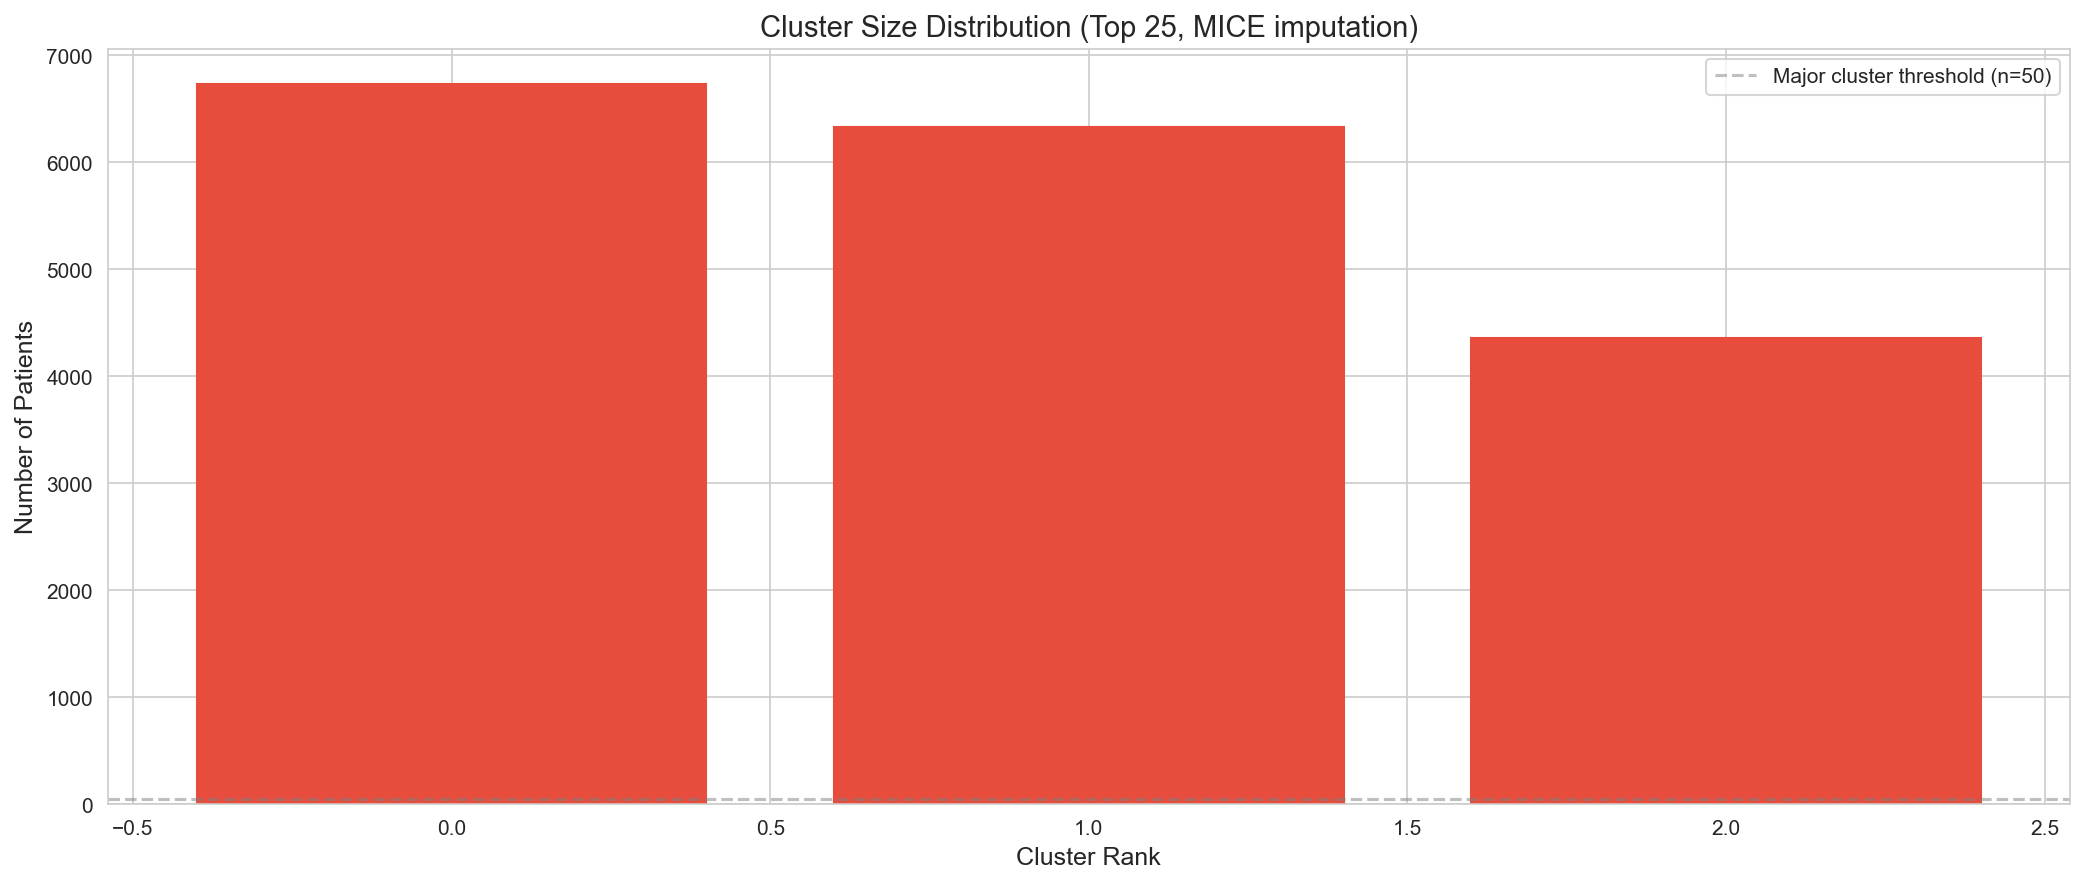

Saved: cluster_size_distribution.png


In [5]:
# Figure: Cluster size distribution (MICE)
labels_mice = infra['cluster_labels']['MICE']
cluster_sizes = pd.Series(labels_mice[labels_mice >= 0]).value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
top_n = min(25, len(cluster_sizes))
bars = ax.bar(range(top_n), cluster_sizes.values[:top_n], color='#3498db', edgecolor='white')

# Highlight major clusters (>50)
for i, v in enumerate(cluster_sizes.values[:top_n]):
    if v > 50:
        bars[i].set_color('#e74c3c')

ax.set_xlabel('Cluster Rank', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Cluster Size Distribution (Top 25, MICE imputation)', fontsize=14)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Major cluster threshold (n=50)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'cluster_size_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: cluster_size_distribution.png')

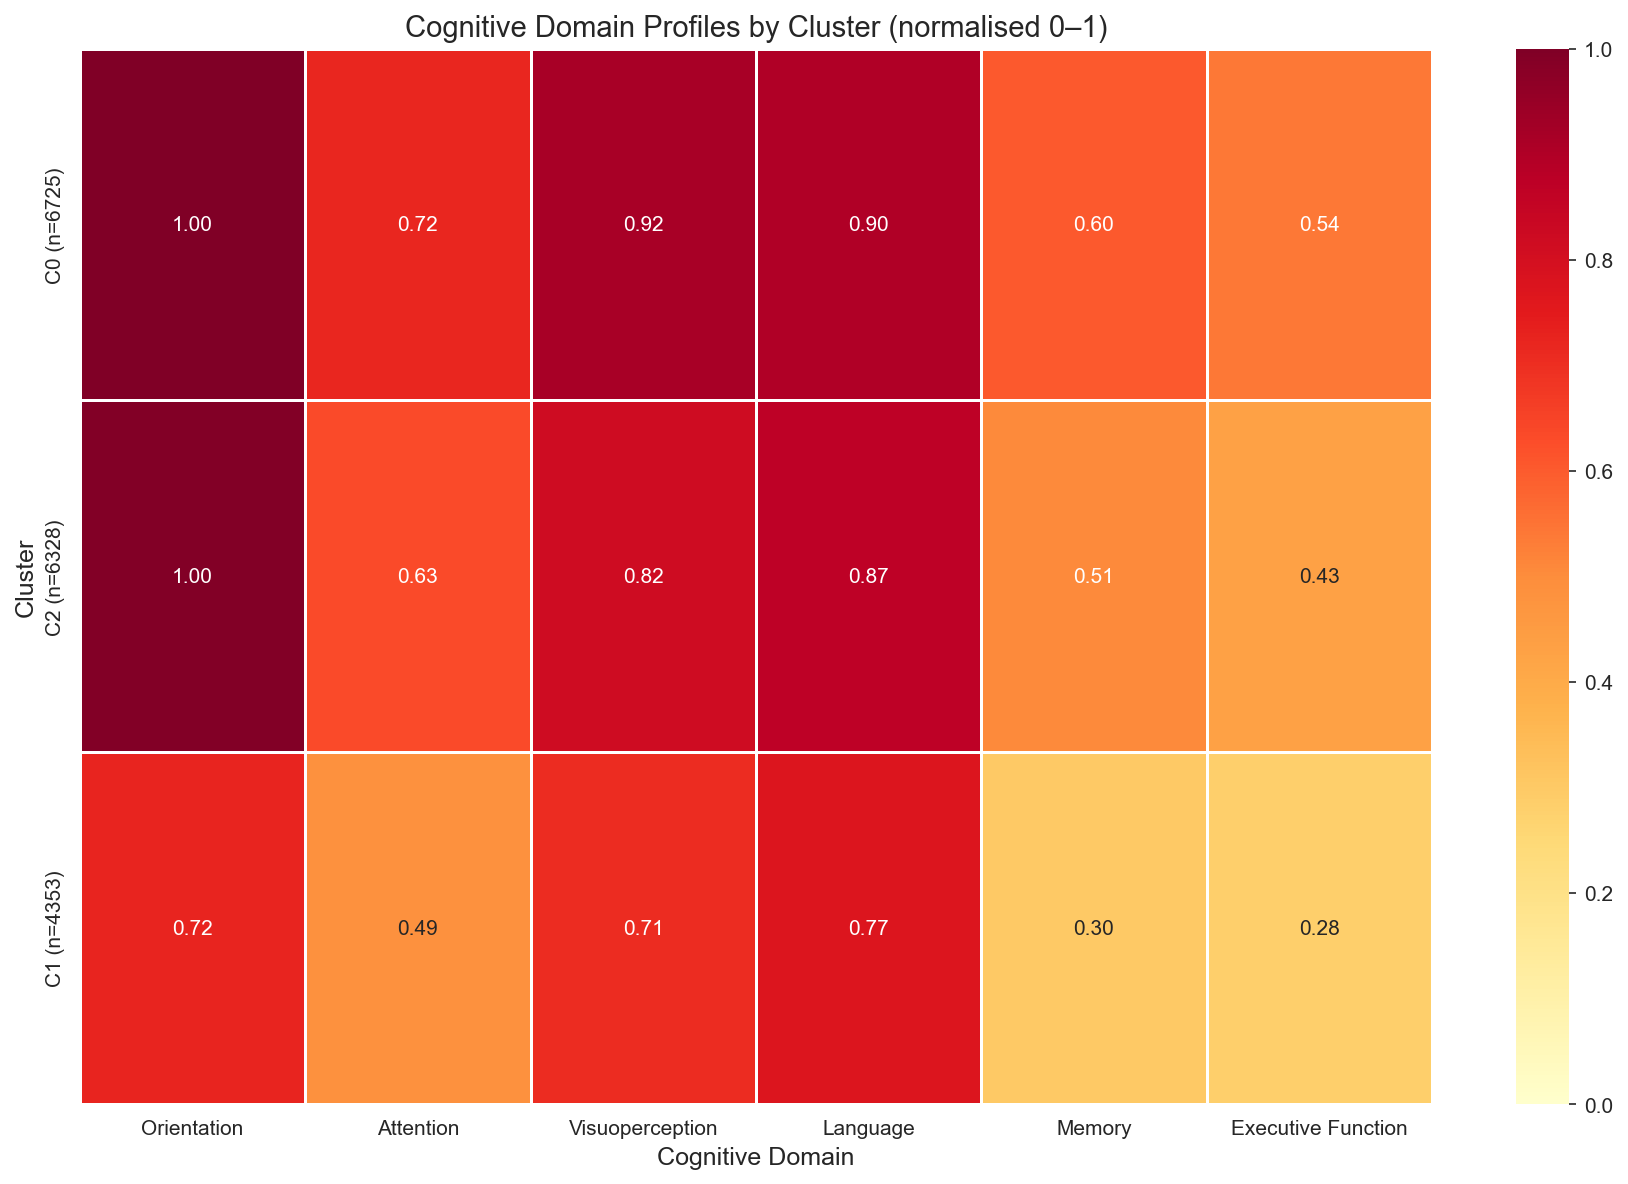

Saved: domain_heatmap_clusters.png


In [6]:
# Figure: Domain heatmap (clusters x domains)
domain_scores_mice = pd.DataFrame(
    infra['domain_scores']['MICE'],
    columns=infra['domain_score_columns'],
    index=infra['domain_score_index']
)

# Normalise
scaler_mm = MinMaxScaler()
domain_norm = pd.DataFrame(
    scaler_mm.fit_transform(domain_scores_mice),
    columns=domain_scores_mice.columns,
    index=domain_scores_mice.index
)

# Top 10 clusters by size
top10 = cluster_sizes.head(10).index.tolist()
heatmap_data = []
for c in top10:
    mask = labels_mice == c
    profile = domain_norm.loc[mask].mean()
    profile.name = f'C{c} (n={mask.sum()})'
    heatmap_data.append(profile)

heatmap_df = pd.DataFrame(heatmap_data)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax,
            vmin=0, vmax=1, annot_kws={'size': 10})
ax.set_xlabel('Cognitive Domain', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title('Cognitive Domain Profiles by Cluster (normalised 0–1)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'domain_heatmap_clusters.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: domain_heatmap_clusters.png')

## 2b. Clinical Cluster Naming

Assign descriptive clinical names to major clusters based on their domain z-score profiles.

In [7]:
# Compute z-scored domain profiles for major clusters
from sklearn.preprocessing import StandardScaler

scaler_z = StandardScaler()
domain_z = pd.DataFrame(
    scaler_z.fit_transform(domain_scores_mice),
    columns=domain_scores_mice.columns,
    index=domain_scores_mice.index
)

# Major clusters (>50 patients)
major_cluster_ids = cluster_sizes[cluster_sizes > 50].index.tolist()

# Compute mean z-score profile per major cluster
cluster_profiles_z = {}
for c in major_cluster_ids:
    mask = labels_mice == c
    profile = domain_z.loc[mask].mean()
    cluster_profiles_z[c] = profile

profiles_df = pd.DataFrame(cluster_profiles_z).T
print('=== Mean Z-Score Profiles (Major Clusters) ===')
print(profiles_df.round(3).to_string())

# Rule-based clinical naming
def name_cluster(profile, domains):
    """Assign a clinical name based on domain z-score pattern."""
    high = profile[profile > 0.5].index.tolist()
    low = profile[profile < -0.5].index.tolist()
    very_low = profile[profile < -1.0].index.tolist()
    very_high = profile[profile > 1.0].index.tolist()
    
    mean_z = profile.mean()
    
    # Global patterns
    if mean_z > 0.5 and len(low) == 0:
        return "High-Functioning"
    if mean_z < -0.5 and len(high) == 0:
        return "Global Impairment"
    
    # Near-normal
    if abs(mean_z) < 0.3 and len(very_low) == 0 and len(very_high) == 0:
        return "Near-Normal"
    
    # Selective deficits
    if len(very_low) == 1:
        return f"{very_low[0]}-Selective Deficit"
    if len(low) == 1 and len(high) >= 2:
        return f"Isolated {low[0]} Weakness"
    
    # Selective strengths
    if len(very_high) == 1 and mean_z < 0:
        return f"Preserved {very_high[0]}"
    
    # Mixed patterns
    if len(low) >= 2 and len(high) >= 1:
        low_str = " & ".join(low[:2])
        return f"Mixed: {low_str} Deficit"
    
    if len(high) >= 2 and len(low) == 0:
        return "Above-Average"
    
    if len(low) >= 2:
        low_str = " & ".join(low[:2])
        return f"{low_str} Impairment"
    
    return "Unclassified Profile"

# Apply naming
cluster_names = {}
for c in major_cluster_ids:
    name = name_cluster(profiles_df.loc[c], domain_scores_mice.columns)
    cluster_names[int(c)] = name

# Also name minor clusters
minor_cluster_ids = [c for c in set(labels_mice) if c >= 0 and c not in major_cluster_ids]
for c in minor_cluster_ids:
    mask = labels_mice == c
    n = mask.sum()
    profile = domain_z.loc[mask].mean()
    name = name_cluster(profile, domain_scores_mice.columns)
    cluster_names[int(c)] = f"{name} (minor, n={n})"

print('\n=== Clinical Cluster Names ===')
for c_id in sorted(cluster_names.keys()):
    n = (labels_mice == c_id).sum()
    print(f'  C{c_id} (n={n:,}): {cluster_names[c_id]}')

# Save
with open(os.path.join(RESULTS_DIR, 'cluster_names.pkl'), 'wb') as f:
    pickle.dump(cluster_names, f, protocol=4)

# Also save as CSV
names_df = pd.DataFrame([
    {'cluster_id': k, 'clinical_name': v, 'n_patients': int((labels_mice == k).sum())}
    for k, v in sorted(cluster_names.items())
])
names_df.to_csv(os.path.join(RESULTS_DIR, 'Cluster_Names.csv'), index=False)

print('\nSaved: cluster_names.pkl, Cluster_Names.csv')

=== Mean Z-Score Profiles (Major Clusters) ===
   Orientation  Attention  Visuoperception  Language  Memory  Executive Function
0        0.416      0.501            0.530     0.371   0.541               0.493
2        0.390      0.019           -0.062     0.091   0.073              -0.020
1       -1.209     -0.802           -0.728    -0.706  -0.942              -0.732

=== Clinical Cluster Names ===
  C0 (n=6,725): Above-Average
  C1 (n=4,353): Global Impairment
  C2 (n=6,328): Near-Normal

Saved: cluster_names.pkl, Cluster_Names.csv


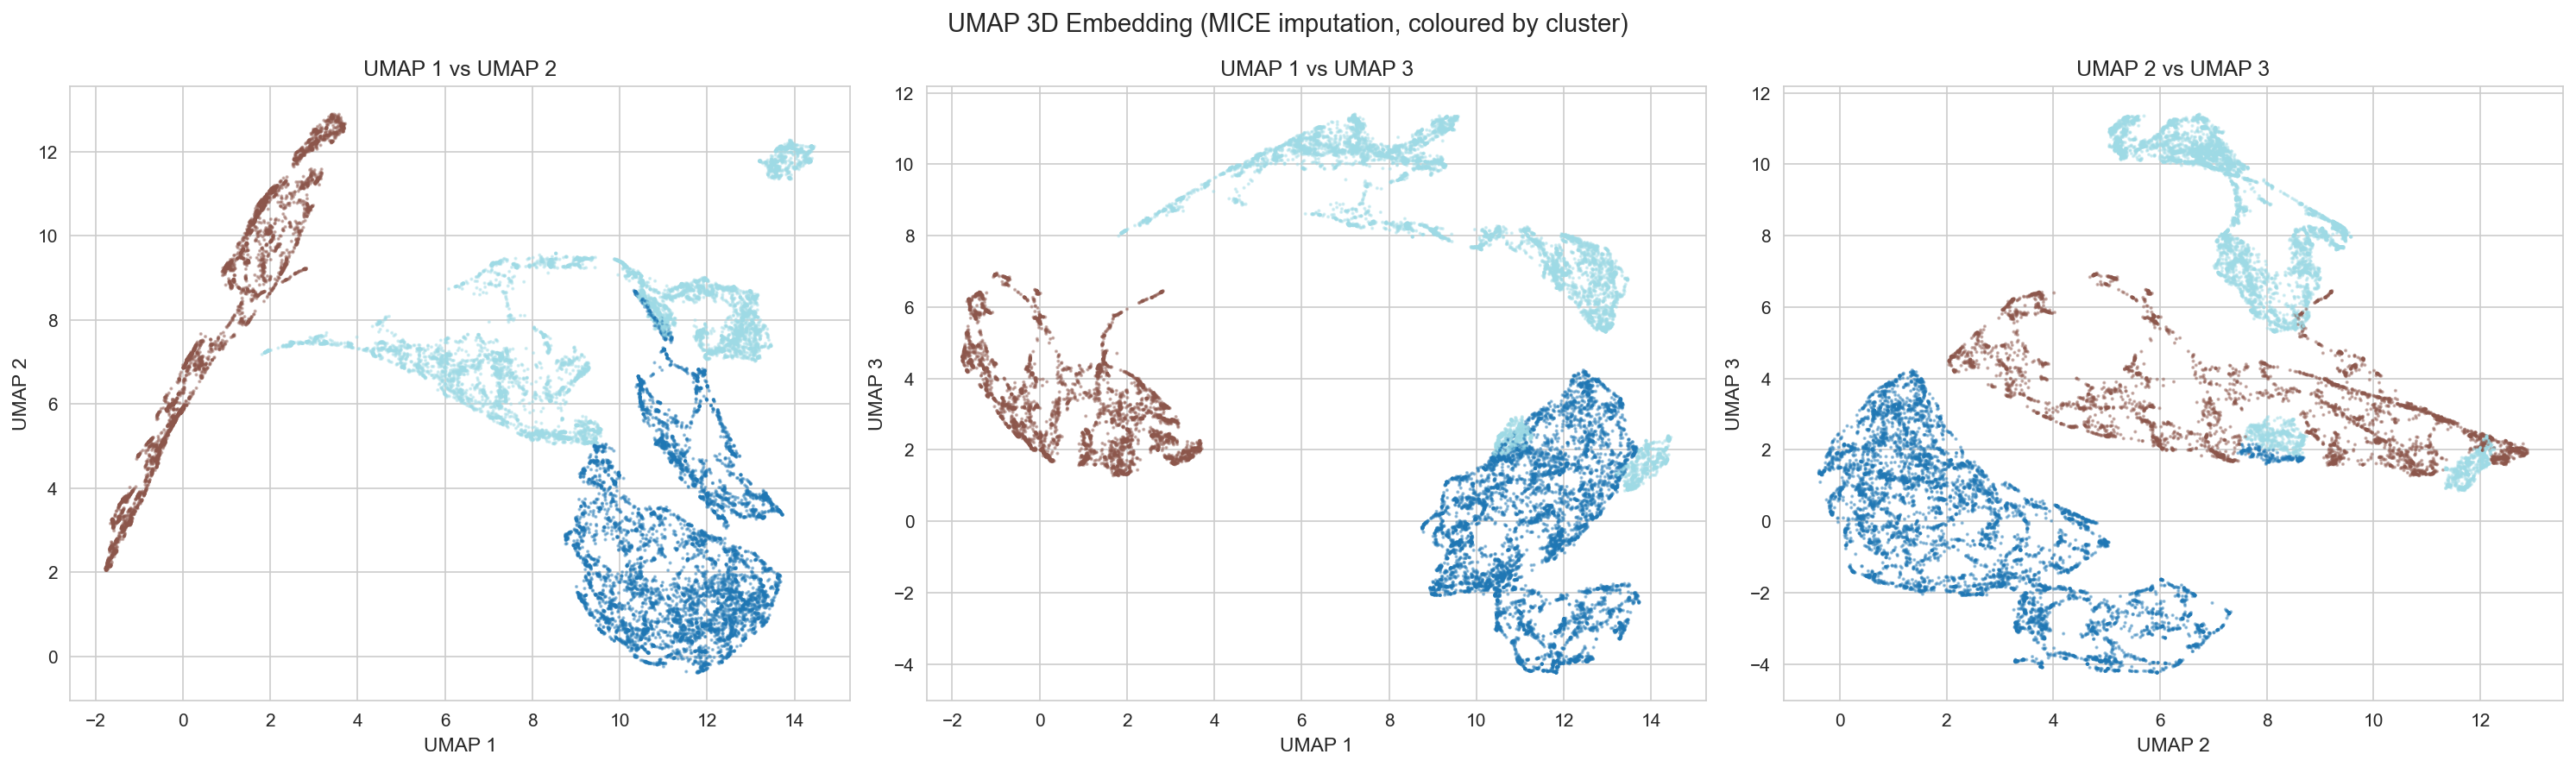

Saved: umap_3d_projections.png


In [8]:
# Figure: UMAP 3D scatter (as 3 2D projections)
emb_mice = infra['umap_embeddings']['MICE']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
projections = [(0, 1, 'UMAP 1', 'UMAP 2'), (0, 2, 'UMAP 1', 'UMAP 3'), (1, 2, 'UMAP 2', 'UMAP 3')]

for ax, (d1, d2, xlabel, ylabel) in zip(axes, projections):
    scatter = ax.scatter(emb_mice[:, d1], emb_mice[:, d2], c=labels_mice, cmap='tab20',
                          s=1, alpha=0.4)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'{xlabel} vs {ylabel}', fontsize=12)

plt.suptitle('UMAP 3D Embedding (MICE imputation, coloured by cluster)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'umap_3d_projections.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: umap_3d_projections.png')

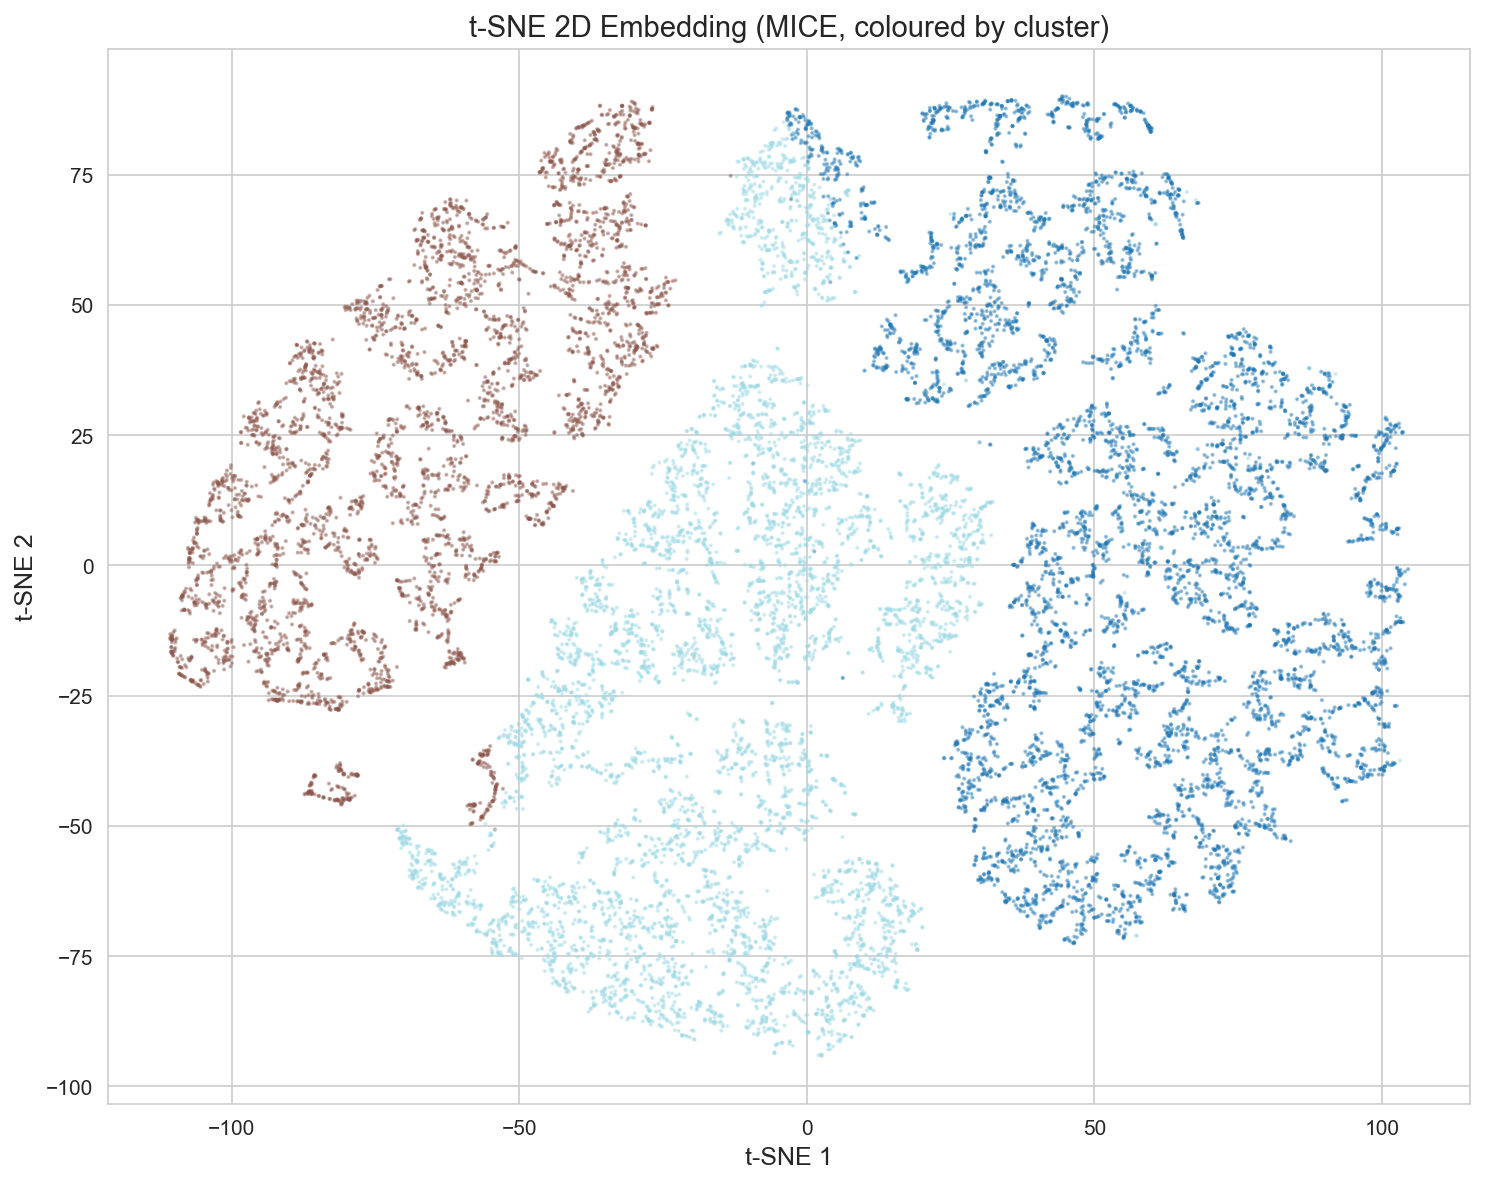

Saved: tsne_2d_clusters.png


In [9]:
# Figure: t-SNE 2D
tsne_2d = infra['tsne_2d']

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(tsne_2d[:, 0], tsne_2d[:, 1], c=labels_mice, cmap='tab20',
                      s=1, alpha=0.4)
ax.set_xlabel('t-SNE 1', fontsize=12)
ax.set_ylabel('t-SNE 2', fontsize=12)
ax.set_title('t-SNE 2D Embedding (MICE, coloured by cluster)', fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'tsne_2d_clusters.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: tsne_2d_clusters.png')

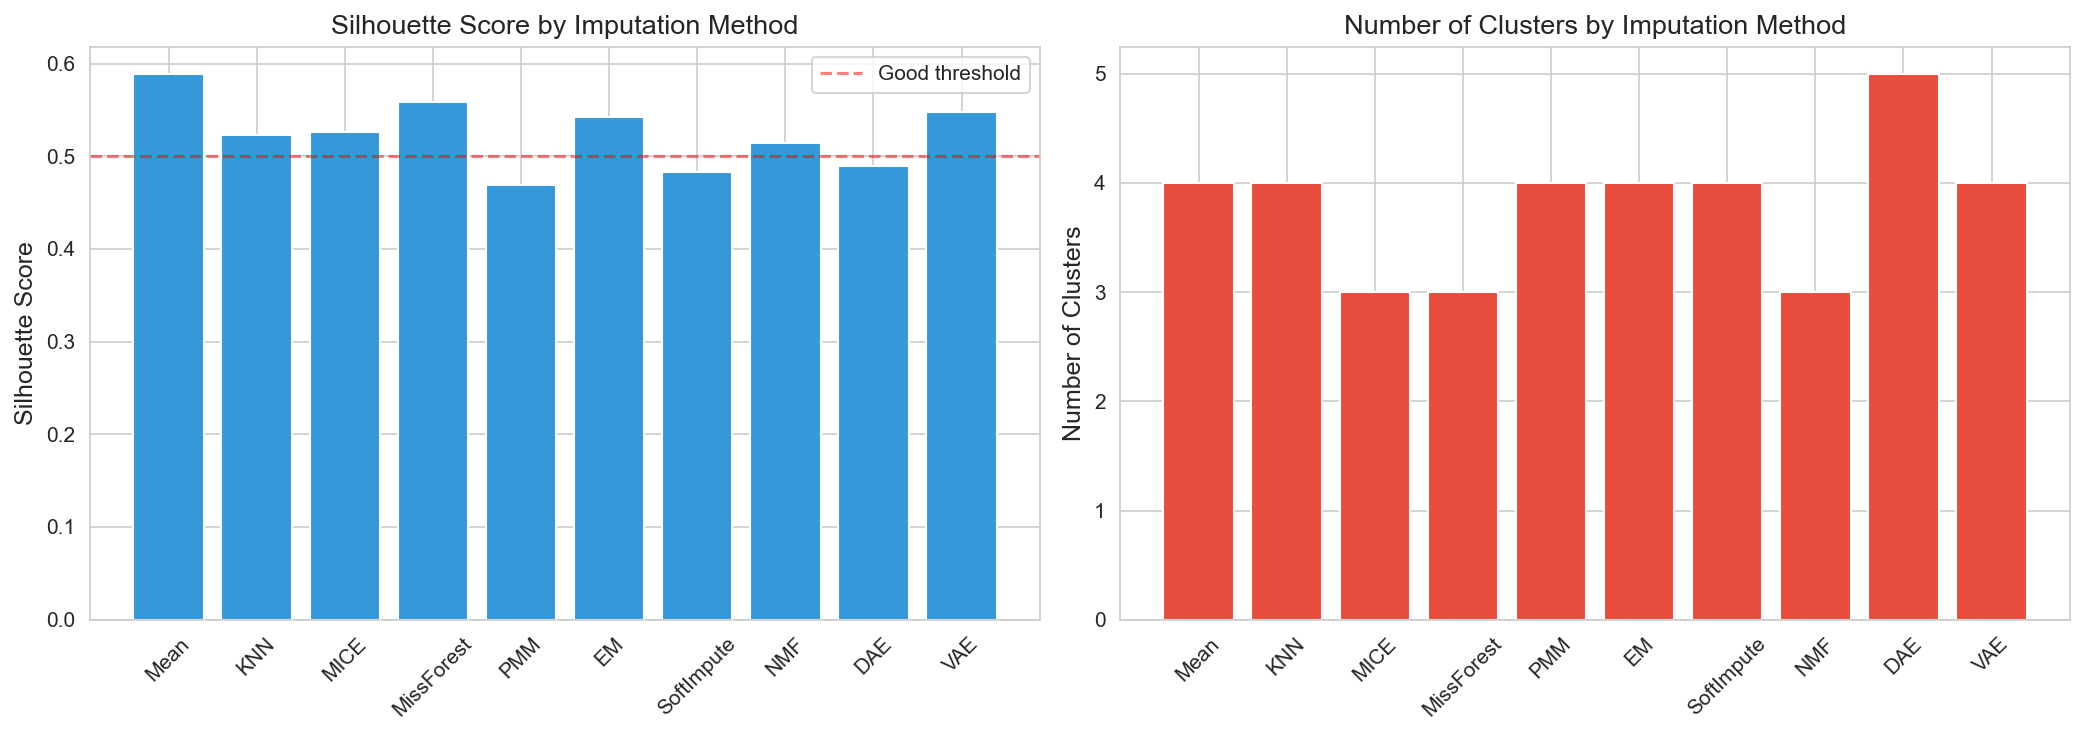

Saved: clustering_by_method.png


In [10]:
# Figure: Clustering metrics by imputation method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(metrics_df['Method'], metrics_df['Silhouette'], color='#3498db', edgecolor='white')
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score by Imputation Method', fontsize=13)
ax1.tick_params(axis='x', rotation=45)
ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Good threshold')
ax1.legend()

ax2.bar(metrics_df['Method'], metrics_df['N Clusters'], color='#e74c3c', edgecolor='white')
ax2.set_ylabel('Number of Clusters', fontsize=12)
ax2.set_title('Number of Clusters by Imputation Method', fontsize=13)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'clustering_by_method.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Saved: clustering_by_method.png')

In [11]:
# Save Final Cluster Assignments with silhouette scores
mask_clustered = labels_mice >= 0
sil_samples = np.full(len(labels_mice), np.nan)
if mask_clustered.sum() > 0:
    sil_samples[mask_clustered] = silhouette_samples(
        emb_mice[mask_clustered], labels_mice[mask_clustered]
    )

final_assignments = pd.DataFrame({
    'cluster': labels_mice,
    'silhouette': sil_samples
}, index=infra['domain_score_index'])

final_assignments.to_csv(os.path.join(RESULTS_DIR, 'Final_Cluster_Assignments.csv'))
print(f'Saved Final_Cluster_Assignments.csv ({len(final_assignments)} patients)')

Saved Final_Cluster_Assignments.csv (17406 patients)


In [12]:
# Final summary
print('\n' + '='*60)
print('FINAL PROJECT SUMMARY')
print('='*60)
print(f'\nDataset: 22,075 assessments → {len(labels_mice):,} after filtering')
print(f'Variables: 51 → {len(ELIGIBLE_VARS)} eligible → {len(DOMAINS)} domain scores')
print(f'Imputation methods: {len(METHODS)}')
print(f'\nClustering (MICE):')
n_c = len(set(labels_mice)) - (1 if -1 in labels_mice else 0)
print(f'  Total clusters: {n_c}')
print(f'  Major clusters (>50): {len(cluster_sizes[cluster_sizes > 50])}')
print(f'  Noise: {(labels_mice == -1).sum()} ({(labels_mice == -1).mean()*100:.1f}%)')
print(f'\nHypothesis Results:')
for _, row in hypothesis_summary.iterrows():
    print(f'  {row["Hypothesis"]}: {row["Verdict"]}')
print(f'\nFigures generated: {len(os.listdir(FIGURES_DIR))} PNG files')
print('='*60)
print('\n=== Notebook 9 Complete ===')


FINAL PROJECT SUMMARY

Dataset: 22,075 assessments → 17,406 after filtering
Variables: 51 → 14 eligible → 6 domain scores
Imputation methods: 10

Clustering (MICE):
  Total clusters: 3
  Major clusters (>50): 3
  Noise: 0 (0.0%)

Hypothesis Results:
  H1: Discrete Cognitive Profiles: Supported
  H2: Imputation Robustness: SUPPORTED
  H3: Clinical Unit Association: SUPPORTED
  H4: Domain vs Variable Level: SUPPORTED

Figures generated: 42 PNG files

=== Notebook 9 Complete ===
